# Proyecto final de Aprendizaje de Máquinas

## Clasificación de presentaciones del Código Único de Medicamentos (CUM)

**Integrantes:** Brayam Arboleda Diaz y Saul Dario Gomez  
**Fuente:** INVIMA — Datos Abiertos Colombia  
**Dataset oficial:** [Código Único de Medicamentos Vigentes](https://www.datos.gov.co/Salud-y-Protecci-n-Social/C-DIGO-NICO-DE-MEDICAMENTOS-VIGENTES/i7cb-raxc/about_data)

Este cuaderno desarrolla el proyecto con las seis fases de **CRISP-DM**:
comprensión del negocio, comprensión de los datos, preparación, modelado,
evaluación y despliegue. Los bloques se ejecutan en orden; no se deben usar
salidas del conjunto de prueba para escoger el modelo.

> **Estado de las salidas:** el generador nunca inventa resultados. La copia
> entregada se ejecuta de principio a fin y conserva tablas, gráficos y
> métricas producidos con el snapshot real. `Entorno de ejecución > Ejecutar
> todas` permite reproducirlos en Colab.


### Prompt 00 — Traducir la guía a un plan CRISP-DM

> Lee la guía del proyecto y conviértela en un plan verificable de seis fases, sin omitir calidad, sesgo, fuga de información, cinco modelos clásicos, votación, bagging, boosting, ajuste por grilla, validación cruzada, prueba final, serialización y aplicación Streamlit.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


## 0. Resumen de ejecución y reglas del experimento

El objetivo de este cuaderno es dejar una trazabilidad completa, no solo
obtener una métrica alta. Las reglas son:

1. Una fila analítica representa una **presentación CUM**, no una fila cruda.
2. Un mismo expediente nunca puede quedar en entrenamiento y prueba.
3. El preprocesamiento y el balanceo se aprenden exclusivamente con los datos
   de entrenamiento de cada partición.
4. La selección se bloquea con validación cruzada antes de mirar el test.
5. Las predicciones son apoyo académico para priorizar revisión; no sustituyen
   una decisión oficial del INVIMA.


### Prompt 01 — Formular el problema de negocio

> Propón un problema de clasificación útil y realista con este conjunto. Define usuario, decisión, variable objetivo, momento de predicción y costos de falsos positivos y falsos negativos. No utilices variables que solo se conocen después del resultado.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


## 1. Comprensión del negocio

**Pregunta:** ¿una presentación farmacéutica propuesta tiene características
estructurales compatibles con una *muestra médica*?

**Uso previsto:** priorizar casos para una revisión humana de consistencia
regulatoria o de empaque antes del registro. La clase positiva es `Sí`.

- Un falso negativo puede dejar sin priorizar una posible muestra médica.
- Un falso positivo consume tiempo de revisión innecesario.
- Por ese equilibrio, **F1** será la métrica principal. También se reportan
  precisión, recall, accuracy, balanced accuracy, ROC-AUC y PR-AUC.
- No se usan fechas posteriores, estado vigente/inactivo, identificadores,
  texto que revele literalmente la clase ni atributos de resultado.


### Prompt 02 — Delimitar riesgos, sesgos y uso responsable

> Enumera los sesgos posibles del corte administrativo, el desbalance de la clase y el riesgo de usar el modelo fuera de alcance. Escribe advertencias concretas para impedir que el resultado se presente como decisión médica o regulatoria.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


### Alcance y advertencias

El archivo es una fotografía administrativa, no una muestra aleatoria de todo
el mercado ni evidencia clínica. Las categorías poco frecuentes, cambios en
prácticas de registro y calidad desigual del texto pueden afectar el modelo.
El resultado no evalúa seguridad, eficacia, calidad terapéutica ni legalidad.
Cualquier uso real exige validación temporal, revisión del INVIMA, monitoreo de
deriva y un procedimiento humano de apelación.


### Prompt 03 — Preparar un entorno reproducible

> Crea una celda que funcione tanto en Google Colab como en una copia local. Si el repositorio no está disponible en Colab, clónalo; luego define rutas relativas y una semilla fija. No uses rutas personales absolutas.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [1]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/Badiaz9226/Proyecto-Final-ML.git"
RANDOM_STATE = 42
EN_COLAB = (
    "google.colab" in sys.modules
    or "COLAB_RELEASE_TAG" in os.environ
    or Path("/content").exists()
)

def encontrar_raiz_proyecto() -> Path:
    candidatos = [Path.cwd(), Path.cwd() / "solucion proyecto final"]
    candidatos.extend(Path.cwd().parents)
    for candidato in candidatos:
        if (candidato / "src" / "train_model.py").exists():
            return candidato.resolve()
    if EN_COLAB:
        destino = Path("/content/Proyecto-Final-ML")
        if not destino.exists():
            subprocess.run(
                ["git", "clone", "--depth", "1", REPO_URL, str(destino)],
                check=True,
            )
        return destino
    raise FileNotFoundError(
        "No se encontró src/train_model.py. Ejecute el cuaderno desde la "
        "raíz del repositorio o clone el proyecto."
    )

RAIZ = encontrar_raiz_proyecto()
DATOS = RAIZ / "data"
REPORTES = RAIZ / "reports"
FIGURAS = RAIZ / "figures"
MODELOS = RAIZ / "models"
for carpeta in (DATOS, REPORTES, FIGURAS, MODELOS):
    carpeta.mkdir(parents=True, exist_ok=True)

print(f"Entorno: {'Google Colab' if EN_COLAB else 'local'}")
print(f"Raíz del proyecto: {RAIZ}")


Entorno: local
Raíz del proyecto: /Users/bryandiaz/Library/CloudStorage/OneDrive-Personal/Maestria/Segundo semestre/Aprendizaje de maquinas/solucion proyecto final


### Prompt 04 — Instalar e importar dependencias

> Instala las versiones declaradas por el repositorio e importa únicamente las librerías necesarias. Registra las versiones para que el experimento pueda repetirse y diagnosticar incompatibilidades.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [2]:
archivo_requisitos = RAIZ / "requirements-dev.txt"
if archivo_requisitos.exists():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(archivo_requisitos)],
        check=True,
    )
else:
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            "pandas", "numpy", "scikit-learn", "imbalanced-learn",
            "matplotlib", "seaborn", "joblib", "ydata-profiling",
        ],
        check=True,
    )

import hashlib
import json
import platform
import urllib.request

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from scipy.stats import friedmanchisquare
from sklearn.base import clone
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import StratifiedGroupKFold

if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from src import train_model

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(RANDOM_STATE)
print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__,
})



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /Users/bryandiaz/Library/CloudStorage/OneDrive-Personal/Maestria/Segundo semestre/Aprendizaje de maquinas/solucion proyecto final/.venv/bin/python -m pip install --upgrade pip


{'python': '3.13.5', 'pandas': '2.3.3', 'numpy': '2.3.5', 'scikit_learn': '1.9.0'}


### Prompt 05 — Registrar fuente y procedencia

> Documenta nombre, publicador, portal, URL oficial, identificador Socrata, fecha del corte y huella SHA-256 del archivo realmente analizado. Si no está en el repositorio, descárgalo desde el endpoint oficial.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [3]:
PAGINA_OFICIAL = (
    "https://www.datos.gov.co/Salud-y-Protecci-n-Social/"
    "C-DIGO-NICO-DE-MEDICAMENTOS-VIGENTES/i7cb-raxc/about_data"
)
DESCARGA_OFICIAL = (
    "https://www.datos.gov.co/api/views/i7cb-raxc/rows.csv?accessType=DOWNLOAD"
)

candidatos_csv = sorted(DATOS.glob("codigo_unico_medicamentos_vigentes*.csv"))
if candidatos_csv:
    RUTA_CSV = candidatos_csv[-1]
    origen_archivo = "copia incluida/local del proyecto"
else:
    RUTA_CSV = DATOS / "codigo_unico_medicamentos_vigentes.csv"
    temporal = RUTA_CSV.with_suffix(".csv.part")
    urllib.request.urlretrieve(DESCARGA_OFICIAL, temporal)
    temporal.replace(RUTA_CSV)
    origen_archivo = "descarga del endpoint oficial durante esta ejecución"

def sha256_archivo(ruta: Path) -> str:
    digest = hashlib.sha256()
    with ruta.open("rb") as archivo:
        for bloque in iter(lambda: archivo.read(1024 * 1024), b""):
            digest.update(bloque)
    return digest.hexdigest()

procedencia = {
    "nombre": "Código Único de Medicamentos Vigentes",
    "publicador": "INVIMA",
    "portal": "Datos Abiertos Colombia",
    "id_socrata": "i7cb-raxc",
    "pagina": PAGINA_OFICIAL,
    "archivo": str(RUTA_CSV),
    "origen_archivo": origen_archivo,
    "bytes": RUTA_CSV.stat().st_size,
    "sha256": sha256_archivo(RUTA_CSV),
}
display(pd.Series(procedencia, name="valor").to_frame())


,valor
nombre,Código Único de Medicamentos Vigentes
publicador,INVIMA
portal,Datos Abiertos Colombia
id_socrata,i7cb-raxc
pagina,https://www.datos.gov.co/Salud-y-Protecci-n-So...
archivo,/Users/bryandiaz/Library/CloudStorage/OneDrive...
origen_archivo,copia incluida/local del proyecto
bytes,75879254
sha256,43cd984ded90ddb8b0bd3d6abdb60a0f7628cd8975cab0...


### Prompt 06 — Cargar y validar el archivo

> Carga el CSV en UTF-8, conserva las columnas originales y detén el proceso si faltan la clave de presentación o la variable objetivo. Muestra una vista acotada, nunca el archivo completo.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [4]:
datos_crudos = pd.read_csv(RUTA_CSV, encoding="utf-8-sig", low_memory=False)
columnas_obligatorias = {"expedientecum", "consecutivocum", "muestramedica"}
faltantes = columnas_obligatorias.difference(datos_crudos.columns)
if faltantes:
    raise ValueError(f"Faltan columnas obligatorias: {sorted(faltantes)}")
if datos_crudos.empty:
    raise ValueError("El archivo no contiene filas.")

print(f"Dimensión cruda: {datos_crudos.shape[0]:,} filas × {datos_crudos.shape[1]} columnas")
display(datos_crudos.head(5))


Dimensión cruda: 155,807 filas × 29 columnas


,expediente,producto,titular,registrosanitario,fechaexpedicion,fechavencimiento,estadoregistro,expedientecum,consecutivocum,cantidadcum,...,concentracion,principioactivo,unidadmedida,cantidad,unidadreferencia,formafarmaceutica,nombrerol,tiporol,modalidad,IUM
0,20048021,CARDIK ® 3 160/5/12.5,LABORATORIOS LEGRAND S.A.,INVIMA 2023M-0013598-R2,08/23/2012,NaN,Vigente,20048021,41,203.0,...,A,HIDROCLOROTIAZIDA,mg,12.5,TABLETA RECUBIERTA,TABLETA RECUBIERTA,LABORATORIOS LEGRANDS.A.,FABRICANTE,FABRICAR Y VENDER,NaN
1,20077715,TRIMEBUTINA200MG + SIMETICONA120MG,TECNOQUIMICAS S.A.,INVIMA 2022M-0016115-R1,08/03/2015,NaN,Vigente,20077715,48,100.0,...,A,TRIMEBUTINA MALEATO,mg,200.0,TABLETA RECUBIERTA,TABLETA RECUBIERTA,TECNOQUIMICAS S.A. (PLANTA JAMUNDI),FABRICANTE,FABRICAR Y VENDER,NaN
2,19924285,TRAMADOL CLORHIDRATO AMPOLLAS 50 MG / 1 ML.,VITALIS S.A.C.I.,INVIMA 2021M-0000733-R2,11/20/2001,NaN,Vigente,19924285,37,2.0,...,C,TRAMADOL CLORHIDRATO,mg,50.0,1 ML,SOLUCION INYECTABLE,VITALIS S.A.C.I. PLANTA 8,FABRICANTE,FABRICAR Y VENDER,NaN
3,45821,RYTMONORM® 300 MG TABLETAS,LABORATORIOS FRANCO COLOMBIANO LAFRANCOL S.A.S,INVIMA 2015M-004879-R3,01/01/1999,NaN,Vigente,45821,20,10.0,...,A,PROPAFENONA CLORHIDRATO,mg,300.0,TABLETA RECUBIERTA,TABLETA CUBIERTA (GRAGEA),ABBOTT LABORATORIES DE COLOMBIA S.A.S.,IMPORTADOR,IMPORTAR Y VENDER,NaN
4,20163993,CARMELUB® PLUS UD,TECNOFAR TQ S.A.S,INVIMA 2021M-0020061,03/12/2021,NaN,Vigente,20163993,5,10.0,...,C,GLICERINA,mg,9.0,ML DE SOLUCIÓN OFTALMICA,SOLUCION OFTALMICA,TECNOFAR TQ S.A.S,FABRICANTE,FABRICAR Y VENDER,NaN


### Prompt 07 — Inspeccionar esquema y tipos

> Resume nombres, tipos inferidos, valores no nulos y cardinalidad. Señala que los tipos automáticos son una hipótesis y que fechas, códigos y cantidades deben validarse antes de modelar.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [5]:
esquema = pd.DataFrame({
    "columna": datos_crudos.columns,
    "tipo_inferido": datos_crudos.dtypes.astype(str).values,
    "no_nulos": datos_crudos.notna().sum().values,
    "porcentaje_nulo": (datos_crudos.isna().mean().values * 100),
    "cardinalidad": datos_crudos.nunique(dropna=True).values,
}).sort_values("porcentaje_nulo", ascending=False)
display(esquema.style.format({"porcentaje_nulo": "{:.2f}%"}))


,columna,tipo_inferido,no_nulos,porcentaje_nulo,cardinalidad
28,IUM,object,32467,79.16%,12434
13,fechainactivo,object,37514,75.92%,2174
5,fechavencimiento,object,45642,70.71%,333
23,unidadreferencia,object,152936,1.84%,2103
4,fechaexpedicion,object,155424,0.25%,3385
10,descripcioncomercial,object,155784,0.01%,62461
17,descripcionatc,object,155807,0.00%,1452
27,modalidad,object,155807,0.00%,5
26,tiporol,object,155807,0.00%,2
25,nombrerol,object,155807,0.00%,2370


### Prompt 08 — Construir el diccionario de datos

> Crea un diccionario que relacione cada columna con su significado operativo, rol analítico y decisión de uso. Distingue identificadores, atributos estructurales, fechas, texto, objetivo y posibles fugas.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [6]:
definiciones = {
    "expediente": "Identificador del expediente del registro sanitario",
    "producto": "Nombre del producto farmacéutico",
    "titular": "Titular del registro sanitario",
    "registrosanitario": "Código del registro sanitario",
    "fechaexpedicion": "Fecha de expedición del registro",
    "fechavencimiento": "Fecha de vencimiento reportada",
    "estadoregistro": "Estado del registro sanitario",
    "expedientecum": "Expediente al que pertenece la presentación CUM",
    "consecutivocum": "Consecutivo de la presentación dentro del expediente",
    "cantidadcum": "Cantidad declarada en la presentación comercial",
    "descripcioncomercial": "Texto de la presentación comercial",
    "estadocum": "Estado de la presentación CUM",
    "fechaactivo": "Fecha de activación de la presentación",
    "fechainactivo": "Fecha de inactivación de la presentación",
    "muestramedica": "Indicador Sí/No de muestra médica; variable objetivo",
    "unidad": "Unidad asociada a la cantidad CUM",
    "atc": "Código de clasificación Anatómica, Terapéutica y Química",
    "descripcionatc": "Descripción del código ATC",
    "viaadministracion": "Vía de administración",
    "concentracion": "Código/categoría de concentración reportada",
    "principioactivo": "Ingrediente activo",
    "unidadmedida": "Unidad de medida del ingrediente",
    "cantidad": "Cantidad del ingrediente",
    "unidadreferencia": "Unidad de referencia del ingrediente",
    "formafarmaceutica": "Forma farmacéutica",
    "nombrerol": "Nombre del actor asociado al registro",
    "tiporol": "Tipo de rol del actor",
    "modalidad": "Modalidad autorizada",
    "IUM": "Identificador Único de Medicamento cuando está disponible",
}
rol_analitico = {
    **{c: "identificador (no predictor)" for c in [
        "expediente", "registrosanitario", "expedientecum", "consecutivocum", "IUM"
    ]},
    **{c: "posterior/estado (excluir por fuga)" for c in [
        "fechaexpedicion", "fechavencimiento", "estadoregistro", "estadocum",
        "fechaactivo", "fechainactivo"
    ]},
    **{c: "texto con riesgo de revelar la clase (excluir)" for c in [
        "producto", "descripcioncomercial", "descripcionatc"
    ]},
    "muestramedica": "objetivo",
    "titular": "alta cardinalidad y posible memorization (excluir)",
}
diccionario = pd.DataFrame({
    "columna": datos_crudos.columns,
    "definicion": [definiciones.get(c, "Validar con el publicador") for c in datos_crudos.columns],
    "rol_analitico": [rol_analitico.get(c, "candidato estructural") for c in datos_crudos.columns],
})
display(diccionario)


,columna,definicion,rol_analitico
0,expediente,Identificador del expediente del registro sani...,identificador (no predictor)
1,producto,Nombre del producto farmacéutico,texto con riesgo de revelar la clase (excluir)
2,titular,Titular del registro sanitario,alta cardinalidad y posible memorization (excl...
3,registrosanitario,Código del registro sanitario,identificador (no predictor)
4,fechaexpedicion,Fecha de expedición del registro,posterior/estado (excluir por fuga)
5,fechavencimiento,Fecha de vencimiento reportada,posterior/estado (excluir por fuga)
6,estadoregistro,Estado del registro sanitario,posterior/estado (excluir por fuga)
7,expedientecum,Expediente al que pertenece la presentación CUM,identificador (no predictor)
8,consecutivocum,Consecutivo de la presentación dentro del expe...,identificador (no predictor)
9,cantidadcum,Cantidad declarada en la presentación comercial,candidato estructural


### Prompt 09 — Determinar el grano real del dataset

> Comprueba si una fila cruda equivale a una presentación. Cuenta combinaciones únicas de expediente y consecutivo, tamaño de cada grupo y repetición por ingredientes, roles y vías. Explica por qué un split aleatorio por filas produciría fuga.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [7]:
clave_cum = ["expedientecum", "consecutivocum"]
tamanos_grupo = datos_crudos.groupby(clave_cum, dropna=False).size()
auditoria_grano = pd.Series({
    "filas_crudas": len(datos_crudos),
    "presentaciones_cum_unicas": tamanos_grupo.size,
    "filas_excedentes_por_explosion": len(datos_crudos) - tamanos_grupo.size,
    "porcentaje_filas_en_grupos_repetidos": 100 * datos_crudos.duplicated(clave_cum, keep=False).mean(),
    "promedio_filas_por_cum": tamanos_grupo.mean(),
    "maximo_filas_por_cum": tamanos_grupo.max(),
}, name="valor")
display(auditoria_grano.to_frame())
display(tamanos_grupo.describe().to_frame("filas_por_presentacion"))


,valor
filas_crudas,155807.000000
presentaciones_cum_unicas,65335.000000
filas_excedentes_por_explosion,90472.000000
porcentaje_filas_en_grupos_repetidos,83.399334
promedio_filas_por_cum,2.384740
maximo_filas_por_cum,92.000000


,filas_por_presentacion
count,65335.000000
mean,2.384740
std,2.864272
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,92.000000


**Cómo interpretar:** si una clave aparece varias veces, esas filas son
manifestaciones de la misma presentación. Separarlas entre train y test haría
que el modelo viera durante el entrenamiento parte del caso que luego se
pretende considerar “no visto”. Por eso primero se consolida a una fila por
CUM y después se agrupa el corte por `expedientecum`.


### Prompt 10 — Auditar duplicados exactos y conflictos

> Cuantifica duplicados exactos, claves incompletas y variación de atributos que deberían ser invariantes dentro de una presentación. No elimines registros solo por repetirse: diferencia duplicación técnica de relaciones uno-a-muchos.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [8]:
invariantes = [
    "muestramedica", "cantidadcum", "formafarmaceutica",
    "concentracion", "unidad", "modalidad",
]
por_presentacion = datos_crudos.groupby(clave_cum, dropna=False)
conflictos = {
    columna: int((por_presentacion[columna].nunique(dropna=False) > 1).sum())
    for columna in invariantes
}
auditoria_duplicados = pd.Series({
    "filas_duplicadas_exactas": int(datos_crudos.duplicated().sum()),
    "filas_con_clave_incompleta": int(datos_crudos[clave_cum].isna().any(axis=1).sum()),
    **{f"presentaciones_con_conflicto_{k}": v for k, v in conflictos.items()},
}, name="conteo")
display(auditoria_duplicados.to_frame())


,conteo
filas_duplicadas_exactas,0
filas_con_clave_incompleta,0
presentaciones_con_conflicto_muestramedica,0
presentaciones_con_conflicto_cantidadcum,0
presentaciones_con_conflicto_formafarmaceutica,0
presentaciones_con_conflicto_concentracion,0
presentaciones_con_conflicto_unidad,0
presentaciones_con_conflicto_modalidad,0


### Prompt 11 — Auditar faltantes y valores centinela

> Calcula nulos por columna y busca cadenas vacías o marcadores como SIN DATO, N/A y guion. Separa ausencia real de errores y no imputes antes de dividir el conjunto.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [9]:
texto_normalizado = datos_crudos.select_dtypes(include="object").apply(
    lambda serie: serie.astype("string").str.strip().str.casefold()
)
centinelas = {"", "sin dato", "sin_dato", "n/a", "na", "-", "no aplica"}
conteo_centinelas = texto_normalizado.isin(centinelas).sum()
calidad_faltantes = pd.DataFrame({
    "nulos": datos_crudos.isna().sum(),
    "porcentaje_nulo": datos_crudos.isna().mean() * 100,
    "centinelas_texto": conteo_centinelas.reindex(datos_crudos.columns, fill_value=0),
}).sort_values(["porcentaje_nulo", "centinelas_texto"], ascending=False)
display(calidad_faltantes.style.format({"porcentaje_nulo": "{:.2f}%"}))


,nulos,porcentaje_nulo,centinelas_texto
IUM,123340,79.16%,0
fechainactivo,118293,75.92%,0
fechavencimiento,110165,70.71%,0
unidadreferencia,2871,1.84%,3723
fechaexpedicion,383,0.25%,0
descripcioncomercial,23,0.01%,6
formafarmaceutica,0,0.00%,304
unidadmedida,0,0.00%,200
expediente,0,0.00%,0
producto,0,0.00%,0


### Prompt 12 — Revisar fechas, codificación y categorías anómalas

> Convierte las fechas con coerción y cuenta valores no interpretables o años fuera de un rango plausible. Busca caracteres de reemplazo y variantes de unidades sin cambiar silenciosamente el archivo fuente.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [10]:
columnas_fecha = [
    "fechaexpedicion", "fechavencimiento", "fechaactivo", "fechainactivo"
]
filas_fechas = []
limite_superior = pd.Timestamp.today().year + 5
for columna in columnas_fecha:
    original = datos_crudos[columna]
    convertida = pd.to_datetime(original, format="%m/%d/%Y", errors="coerce")
    filas_fechas.append({
        "columna": columna,
        "no_nulos_originales": int(original.notna().sum()),
        "no_interpretables": int((original.notna() & convertida.isna()).sum()),
        "anio_menor_1950": int((convertida.dt.year < 1950).sum()),
        "anio_mayor_limite": int((convertida.dt.year > limite_superior).sum()),
    })
display(pd.DataFrame(filas_fechas))

caracteres_reemplazo = datos_crudos.select_dtypes(include="object").apply(
    lambda serie: serie.astype("string").str.contains("�", regex=False, na=False).sum()
)
display(caracteres_reemplazo[caracteres_reemplazo > 0].to_frame("filas_con_caracter_reemplazo"))
display(datos_crudos["unidadmedida"].value_counts(dropna=False).head(25).to_frame("filas"))


,columna,no_nulos_originales,no_interpretables,anio_menor_1950,anio_mayor_limite
0,fechaexpedicion,155424,0,0,0
1,fechavencimiento,45642,31550,622,237
2,fechaactivo,155807,0,0,0
3,fechainactivo,37514,29,1543,0


,filas_con_caracter_reemplazo
descripcioncomercial,22


,filas
unidadmedida,
mg,119599
g,21961
mcg,3959
UI,2212
mg.,1192
%,932
IU,677
% (V/V),533
æg,510


### Prompt 13 — Validar la variable objetivo

> Lista todas las etiquetas de muestra médica, verifica que solo existan Sí y No después de normalizar acentos y detén el análisis ante una etiqueta desconocida. No conviertas silenciosamente valores extraños en clase negativa.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [11]:
etiquetas_objetivo = datos_crudos["muestramedica"].value_counts(dropna=False)
display(etiquetas_objetivo.to_frame("filas_crudas"))
# Esta llamada valida explícitamente cada etiqueta y falla si hay deriva.
objetivo_validado = datos_crudos["muestramedica"].map(train_model._normalize_target)
print("Etiquetas válidas:", sorted(objetivo_validado.unique().tolist()))


,filas_crudas
muestramedica,
No,119997
Si,35810


Etiquetas válidas: [0, 1]


### Prompt 14 — Consolidar a una fila por presentación CUM

> Agrupa por expediente CUM y consecutivo. Conserva atributos invariantes, combina categorías multivaluadas sin duplicarlas y crea conteos estructurales. No promedies cantidades de ingredientes que usan unidades incompatibles.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [12]:
datos_modelo = train_model.build_modeling_table(datos_crudos.copy())
if datos_modelo.duplicated(train_model.KEY_COLUMNS).any():
    raise AssertionError("La tabla modelada aún contiene claves CUM repetidas.")

print(f"Tabla analítica: {datos_modelo.shape[0]:,} presentaciones × {datos_modelo.shape[1]} columnas")
display(datos_modelo.head(5))


Tabla analítica: 65,335 presentaciones × 21 columnas


,expedientecum,consecutivocum,cantidad_cum,forma_farmaceutica,codigo_concentracion,unidad_cum,modalidad,vias_administracion,unidades_medida,familias_atc,...,numero_cantidades_ingrediente_distintas,numero_principios_activos,tipos_rol,numero_vias_administracion,numero_codigos_atc,numero_unidades_medida,numero_unidades_referencia,numero_tipos_rol,numero_actores,es_muestra_medica
0,20048021,41,203.0,TABLETA RECUBIERTA,A,U,FABRICAR Y VENDER,ORAL,mg,C,...,3.0,3.0,FABRICANTE,1.0,1.0,1.0,1.0,1.0,1.0,0
1,20077715,48,100.0,TABLETA RECUBIERTA,A,U,FABRICAR Y VENDER,ORAL,mg,A,...,2.0,2.0,FABRICANTE,1.0,2.0,1.0,1.0,1.0,1.0,0
2,19924285,37,2.0,SOLUCION INYECTABLE,C,U,FABRICAR Y VENDER,INTRAMUSCULAR | INTRAVENOSA | SUBCUTANEA,mg,N,...,1.0,1.0,FABRICANTE,3.0,1.0,1.0,1.0,1.0,1.0,0
3,45821,20,10.0,TABLETA CUBIERTA (GRAGEA),A,U,IMPORTAR Y VENDER,ORAL,mg,C,...,1.0,1.0,FABRICANTE | IMPORTADOR,1.0,1.0,1.0,1.0,2.0,5.0,0
4,20163993,5,10.0,SOLUCION OFTALMICA,C,U,FABRICAR Y VENDER,OFTÁLMICA,mg,S,...,2.0,2.0,FABRICANTE,1.0,1.0,1.0,1.0,1.0,1.0,1


### Informe automático de perfil de datos

Además de las comprobaciones explícitas —que siguen siendo la fuente de las
decisiones metodológicas— se genera el HTML solicitado con `ydata-profiling`.
El modo mínimo evita asociaciones costosas en campos de alta cardinalidad; no
reemplaza la auditoría de grano, fuga ni fechas realizada arriba.


In [13]:
from ydata_profiling import ProfileReport

ruta_perfil = REPORTES / "reporte_ydata_profiling.html"
if ruta_perfil.exists():
    print(f"Perfil ydata completo ya verificado; se reutiliza: {ruta_perfil}")
else:
    perfil = ProfileReport(
        datos_crudos,
        title="Perfil de datos — Código Único de Medicamentos Vigentes",
        minimal=True,
        explorative=False,
    )
    perfil.to_file(ruta_perfil)
    print(f"Perfil ydata guardado en: {ruta_perfil}")


Perfil ydata completo ya verificado; se reutiliza: /Users/bryandiaz/Library/CloudStorage/OneDrive-Personal/Maestria/Segundo semestre/Aprendizaje de maquinas/solucion proyecto final/reports/reporte_ydata_profiling.html


/var/folders/q4/_251z6mn6130gn78j4d9lfsh0000gn/T/ipykernel_21025/2071696141.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


### Prompt 15 — Describir la distribución del objetivo y las líneas base

> Calcula prevalencia por presentación, accuracy de la clase mayoritaria y PR-AUC esperada al azar. Grafica conteos y porcentajes con etiquetas legibles.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


,clase,presentaciones,porcentaje
0,No,51243,78.43%
1,Sí,14092,21.57%


Accuracy de mayoría: 0.7843
PR-AUC aleatoria (prevalencia positiva): 0.2157


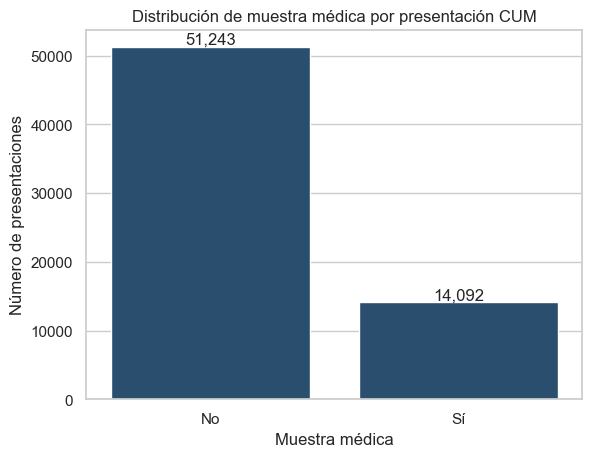

In [14]:
distribucion = datos_modelo[train_model.TARGET_COLUMN].value_counts().sort_index()
resumen_objetivo = pd.DataFrame({
    "clase": ["No", "Sí"],
    "presentaciones": [distribucion.get(0, 0), distribucion.get(1, 0)],
})
resumen_objetivo["porcentaje"] = 100 * resumen_objetivo["presentaciones"] / len(datos_modelo)
display(resumen_objetivo.style.format({"porcentaje": "{:.2f}%"}))
print(f"Accuracy de mayoría: {distribucion.max() / distribucion.sum():.4f}")
print(f"PR-AUC aleatoria (prevalencia positiva): {distribucion.get(1, 0) / distribucion.sum():.4f}")

ax = sns.barplot(data=resumen_objetivo, x="clase", y="presentaciones", color="#1F4E79")
ax.set(title="Distribución de muestra médica por presentación CUM",
       xlabel="Muestra médica", ylabel="Número de presentaciones")
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="{:,.0f}")
plt.show()


### Prompt 16 — Detectar fuga de información y sesgo de memorización

> Mide cuánto revelan literalmente la clase el nombre del producto y la descripción comercial. Comprueba además la repetición de expedientes. Usa el hallazgo para excluir esos textos e imponer particiones por expediente.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [15]:
texto_fuga = (
    datos_crudos[["producto", "descripcioncomercial"]]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("ascii")
    .str.casefold()
)
regla_textual = texto_fuga.str.contains(r"muestra\s+medica", regex=True)
tabla_fuga = pd.crosstab(
    objetivo_validado,
    regla_textual,
    rownames=["objetivo"],
    colnames=["texto_contiene_muestra_medica"],
)
display(tabla_fuga)
print("Expedientes únicos:", datos_modelo[train_model.GROUP_COLUMN].nunique())
print("Presentaciones:", len(datos_modelo))


texto_contiene_muestra_medica,False,True
objetivo,,
0,119358,639
1,3808,32002


Expedientes únicos: 9520
Presentaciones: 65335


**Decisión metodológica:** `producto` y `descripcioncomercial` no se convierten
en predictores. Aunque elevaran la métrica, podrían incluir la respuesta de
forma literal. Tampoco se emplean identificadores para memorizar casos, ni
fechas/estados posteriores. Esta renuncia deliberada protege la validez del
experimento.


### Prompt 17 — Seleccionar variables disponibles en inferencia

> Presenta las variables finales y justifica su disponibilidad antes del resultado. Incluye cantidad CUM, forma, concentración, unidad, modalidad, vías, familias ATC, unidades y conteos estructurales; excluye identificadores, texto revelador, fechas y estado.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [16]:
seleccion_variables = pd.DataFrame({
    "variable": train_model.MODEL_FEATURES,
    "tipo": [
        "numérica" if v in train_model.NUMERIC_FEATURES else "categórica"
        for v in train_model.MODEL_FEATURES
    ],
    "momento": "disponible en el planteamiento estructural de la presentación",
})
display(seleccion_variables)

X = datos_modelo[train_model.MODEL_FEATURES].copy()
y = datos_modelo[train_model.TARGET_COLUMN].astype(int)
grupos = datos_modelo[train_model.GROUP_COLUMN].astype(str)


,variable,tipo,momento
0,cantidad_cum,numérica,disponible en el planteamiento estructural de ...
1,numero_filas_fuente,numérica,disponible en el planteamiento estructural de ...
2,numero_cantidades_ingrediente_distintas,numérica,disponible en el planteamiento estructural de ...
3,numero_principios_activos,numérica,disponible en el planteamiento estructural de ...
4,numero_vias_administracion,numérica,disponible en el planteamiento estructural de ...
5,numero_codigos_atc,numérica,disponible en el planteamiento estructural de ...
6,numero_unidades_medida,numérica,disponible en el planteamiento estructural de ...
7,numero_unidades_referencia,numérica,disponible en el planteamiento estructural de ...
8,numero_tipos_rol,numérica,disponible en el planteamiento estructural de ...
9,numero_actores,numérica,disponible en el planteamiento estructural de ...


### Prompt 18 — Crear el holdout 70/30 sin fuga de expedientes

> Separa aproximadamente 70% para entrenamiento y 30% para prueba con estratificación agrupada. Todos los CUM de un expediente deben permanecer en el mismo lado. Fija la semilla y conserva el test intacto.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [17]:
mascara_train, mascara_test, asignacion_folds = train_model.make_holdout_split(X, y, grupos)
X_train, X_test = X.loc[mascara_train].copy(), X.loc[mascara_test].copy()
y_train, y_test = y.loc[mascara_train].copy(), y.loc[mascara_test].copy()
grupos_train = grupos.loc[mascara_train].copy()

resumen_particion = pd.DataFrame({
    "particion": ["entrenamiento", "prueba"],
    "filas": [len(X_train), len(X_test)],
    "porcentaje": [100 * len(X_train) / len(X), 100 * len(X_test) / len(X)],
    "tasa_positiva": [y_train.mean(), y_test.mean()],
    "expedientes": [grupos_train.nunique(), grupos.loc[mascara_test].nunique()],
})
display(resumen_particion.style.format({
    "porcentaje": "{:.2f}%", "tasa_positiva": "{:.4f}"
}))


,particion,filas,porcentaje,tasa_positiva,expedientes
0,entrenamiento,45740,70.01%,0.2158,6706
1,prueba,19595,29.99%,0.2155,2814


### Prompt 19 — Demostrar que la partición es válida

> Agrega pruebas automáticas de ausencia de expedientes compartidos, cobertura de todas las filas, proporción aproximada 70/30 y presencia de ambas clases en los dos conjuntos.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [18]:
interseccion = set(grupos.loc[mascara_train]) & set(grupos.loc[mascara_test])
assert not interseccion, f"Fuga detectada en {len(interseccion)} expedientes"
assert int(mascara_train.sum() + mascara_test.sum()) == len(X)
assert 0.65 <= mascara_train.mean() <= 0.75
assert y_train.nunique() == 2 and y_test.nunique() == 2
assert set(np.unique(asignacion_folds)) == set(range(10))
print("Comprobaciones superadas: test aislado por expediente y ambas clases presentes.")


Comprobaciones superadas: test aislado por expediente y ambas clases presentes.


### Prompt 20 — Diseñar el preprocesamiento dentro del pipeline

> Construye un ColumnTransformer: mediana, log1p y escalamiento para numéricas; imputación y one-hot con categorías desconocidas para categóricas; y vectorización binaria para campos multivaluados. Evalúa también la reducción de dimensiones: conserva el espacio interpretable para todos los modelos y aplica TruncatedSVD de 30 componentes únicamente a KNN, dentro de cada fold, porque las distancias exactas en la matriz one-hot dispersa son costosas y poco informativas. Todo debe ajustarse solo dentro de cada fold.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [19]:
preprocesador = train_model.make_preprocessor()
print(preprocesador)
print("Numéricas:", train_model.NUMERIC_FEATURES)
print("Categóricas simples:", train_model.SINGLE_CATEGORICAL_FEATURES)
print("Categóricas multivaluadas:", train_model.MULTI_CATEGORICAL_FEATURES)


ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('log1p',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['cantidad_cum', 'numero_filas_fuente',
                                  'numero_cantidades_ingrediente_distintas',
                                  'numero_principios_activos',
                                  'numero_vias_administracio...
                                                 tokenizer=<function split_pipe_tokens at 0x11daef9c0>),
                                 'unidades_medida'),
                                ('multi

**Decisión sobre reducción dimensional:** no se aplica PCA/SVD de forma global,
pues se desea conservar la interpretación de las variables. La única excepción
es KNN: su pipeline incorpora `TruncatedSVD(n_components=30)` después del
preprocesamiento y antes del sobremuestreo. El SVD se aprende dentro de cada
fold; así se evitan fuga y el cálculo prohibitivo de distancias sobre una matriz
one-hot dispersa de alta dimensión.


### Prompt 21 — Manejar el desbalance sin contaminar la validación

> Integra RandomOverSampler después del preprocesamiento y antes del modelo. Explica por qué debe vivir dentro de imblearn.Pipeline y nunca aplicarse al dataset completo ni al test.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [20]:
from sklearn.linear_model import LogisticRegression

ejemplo_pipeline = train_model.make_pipeline(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
)
print(ejemplo_pipeline)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log1p',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['cantidad_cum',
                                                   'numero_filas_fuente',
                                                   'numero_cantidades_ingrediente_distintas',
                      

Al vivir dentro del pipeline, el sobremuestreo recibe únicamente la fracción
de entrenamiento de cada fold. El fold de validación y el test conservan la
distribución observada. Balancear antes del corte duplicaría información y
produciría una evaluación artificialmente optimista.


### Prompt 22 — Justificar las métricas

> Define accuracy, precision, recall, F1, balanced accuracy, ROC-AUC y PR-AUC. Elige una métrica principal coherente con la clase minoritaria y con los costos de error; conserva una línea base de mayoría y otra de prevalencia.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


## 4. Modelado — métricas

- **Precision:** de los casos marcados como muestra, cuántos realmente lo son.
- **Recall:** de las muestras reales, cuántas se logran priorizar.
- **F1:** media armónica de precision y recall; es la métrica de selección.
- **Accuracy:** aciertos globales; puede ser engañosa con desbalance.
- **Balanced accuracy:** promedio del recall de ambas clases.
- **ROC-AUC:** capacidad de ordenamiento en todos los umbrales.
- **PR-AUC:** precisión-recall; se compara con la prevalencia positiva.

F1 refleja el compromiso operativo entre omitir posibles muestras y generar
revisiones innecesarias. Las demás métricas impiden esconder el costo detrás
de un único número.


### Prompt 23 — Definir validación cruzada agrupada

> Usa cinco folds de StratifiedGroupKFold exclusivamente sobre el 70% de entrenamiento. Materializa una vez las particiones para comparar todos los modelos sobre exactamente los mismos casos.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [21]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
particiones_cv = list(cv.split(X_train, y_train, grupos_train))
control_folds = []
for numero, (indice_ajuste, indice_validacion) in enumerate(particiones_cv, 1):
    grupos_ajuste = set(grupos_train.iloc[indice_ajuste])
    grupos_validacion = set(grupos_train.iloc[indice_validacion])
    assert not (grupos_ajuste & grupos_validacion)
    control_folds.append({
        "fold": numero,
        "filas_ajuste": len(indice_ajuste),
        "filas_validacion": len(indice_validacion),
        "tasa_positiva_validacion": y_train.iloc[indice_validacion].mean(),
        "expedientes_validacion": len(grupos_validacion),
    })
display(pd.DataFrame(control_folds))


,fold,filas_ajuste,filas_validacion,tasa_positiva_validacion,expedientes_validacion
0,1,36583,9157,0.216010,1373
1,2,36596,9144,0.215661,1324
2,3,36596,9144,0.215770,1342
3,4,36591,9149,0.215761,1310
4,5,36594,9146,0.215613,1357


### Prompt 24 — Configurar cinco modelos clásicos

> Incluye regresión logística, SVM lineal, red neuronal MLP, árbol de decisión y K vecinos más cercanos con semillas y valores iniciales explícitos. Explica qué tipo de frontera o relación puede capturar cada uno.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [22]:
catalogo = train_model.model_catalog()
modelos_clasicos = [
    "Regresion logistica", "SVM lineal", "Red neuronal MLP",
    "Arbol de decision", "K vecinos mas cercanos",
]
display(pd.DataFrame({
    "modelo": modelos_clasicos,
    "idea": [
        "frontera lineal e interpretable",
        "máximo margen en el espacio transformado",
        "relaciones no lineales mediante capas ocultas",
        "reglas e interacciones no lineales",
        "similitud local entre presentaciones",
    ],
    "configuracion": [str(catalogo[n]) for n in modelos_clasicos],
}))


,modelo,idea,configuracion
0,Regresion logistica,frontera lineal e interpretable,"LogisticRegression(max_iter=2000, random_state..."
1,SVM lineal,máximo margen en el espacio transformado,"LinearSVC(max_iter=100000, random_state=42, to..."
2,Red neuronal MLP,relaciones no lineales mediante capas ocultas,"MLPClassifier(alpha=0.001, early_stopping=True..."
3,Arbol de decision,reglas e interacciones no lineales,"DecisionTreeClassifier(max_depth=12, min_sampl..."
4,K vecinos mas cercanos,similitud local entre presentaciones,"KNeighborsClassifier(n_jobs=-1, n_neighbors=21..."


### Prompt 25 — Agregar ensembles de votación, bagging y boosting

> Construye un VotingClassifier, un BaggingClassifier y AdaBoost. Mantén cada ensemble dentro del mismo pipeline y describe la diversidad, reducción de varianza o corrección secuencial que busca cada estrategia.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [23]:
modelos_ensemble = ["Votacion", "Bagging", "Boosting AdaBoost"]
display(pd.DataFrame({
    "modelo": modelos_ensemble,
    "objetivo": [
        "combinar decisiones de familias diferentes",
        "reducir varianza promediando árboles remuestreados",
        "corregir secuencialmente los casos difíciles",
    ],
    "configuracion": [str(catalogo[n]) for n in modelos_ensemble],
}))


,modelo,objetivo,configuracion
0,Votacion,combinar decisiones de familias diferentes,"VotingClassifier(estimators=[('logistic',\n ..."
1,Bagging,reducir varianza promediando árboles remuestre...,BaggingClassifier(estimator=DecisionTreeClassi...
2,Boosting AdaBoost,corregir secuencialmente los casos difíciles,AdaBoostClassifier(estimator=DecisionTreeClass...


### Prompt 26 — Ejecutar la comparación completa sin mirar el test

> Evalúa los ocho modelos, ajusta las grillas de logística y SVM, compara folds alineados, bloquea la elección y solo después evalúa una vez el holdout. Centraliza el procedimiento en una función versionada para que Colab, el script y la aplicación utilicen exactamente la misma lógica.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [24]:
# Este bloque es el de mayor duración. La función conserva el test aislado,
# ajusta cada transformación dentro de CV y devuelve todos los artefactos.
EJECUTAR_ENTRENAMIENTO_COMPLETO = True
if not EJECUTAR_ENTRENAMIENTO_COMPLETO:
    raise RuntimeError(
        "Cambie EJECUTAR_ENTRENAMIENTO_COMPLETO a True para producir resultados reales."
    )

artefactos = train_model.train_and_evaluate(datos_crudos.copy())
resultados = artefactos.results
print("Entrenamiento y evaluación terminados con datos reales.")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Entrenamiento y evaluación terminados con datos reales.


### Prompt 27 — Comparar los modelos en validación cruzada

> Ordena la media y desviación de F1 de los modelos. Incluye train F1 para diagnóstico, barras de error y los valores por fold; no declares ganador por una diferencia mínima sin evaluar incertidumbre y complejidad.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


,modelo,f1_media_validacion,f1_desviacion,f1_media_train,roc_auc_media,pr_auc_media
6,Bagging,0.5061,0.0032,0.5501,0.7823,0.5069
5,Votacion,0.5016,0.0066,0.5434,0.7791,0.4962
2,Red neuronal MLP,0.4918,0.0065,0.5463,0.7671,0.4604
3,Arbol de decision,0.4880,0.0114,0.5284,0.7578,0.4687
9,SVM lineal ajustada,0.4874,0.0113,0.4976,0.7605,0.4345
7,Boosting AdaBoost,0.4862,0.0128,0.4874,0.7632,0.4561
8,Regresion logistica ajustada,0.4851,0.0104,0.4981,0.7626,0.4430
0,Regresion logistica,0.4846,0.0097,0.4998,0.7615,0.4394
1,SVM lineal,0.4831,0.0086,0.4988,0.7604,0.4378
4,K vecinos mas cercanos,0.4700,0.0098,0.6031,0.7428,0.4454


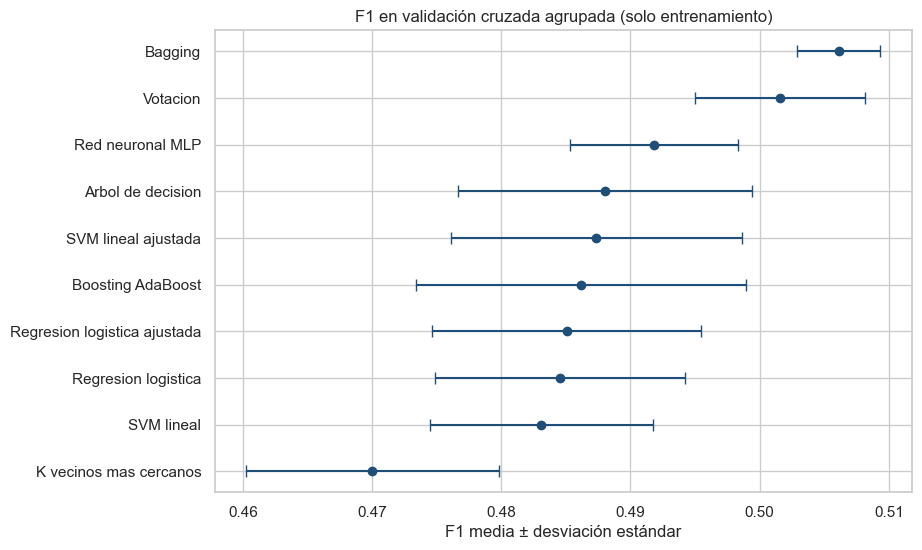

,modelo,fold,accuracy,precision,recall,f1,balanced_accuracy,roc_auc,pr_auc,train_f1
15,Arbol de decision,1,0.634815,0.342844,0.753286,0.471221,0.677730,0.746822,0.457939,0.525558
16,Arbol de decision,2,0.680009,0.376871,0.740365,0.499487,0.701889,0.770981,0.479079,0.522643
17,Arbol de decision,3,0.665245,0.367188,0.762291,0.495634,0.700418,0.769095,0.479476,0.524391
18,Arbol de decision,4,0.669253,0.364083,0.713779,0.482204,0.685391,0.740711,0.467246,0.526394
19,Arbol de decision,5,0.698994,0.386581,0.674949,0.491597,0.690276,0.761171,0.459806,0.543032
30,Bagging,1,0.690401,0.385090,0.725986,0.503242,0.703291,0.776324,0.516952,0.550245
31,Bagging,2,0.697616,0.391161,0.722617,0.507569,0.706679,0.787952,0.503522,0.546760
32,Bagging,3,0.699147,0.393366,0.727319,0.510585,0.709357,0.786157,0.513496,0.548371
33,Bagging,4,0.702372,0.394299,0.707700,0.506435,0.704303,0.782107,0.513811,0.549848
34,Bagging,5,0.705882,0.395579,0.689655,0.502773,0.699999,0.778982,0.486539,0.555407


In [25]:
resumenes_cv = {**resultados["cv_summary"], **resultados["tuned_cv_summary"]}
tabla_cv = pd.DataFrame([
    {
        "modelo": nombre,
        "f1_media_validacion": metricas["f1"]["mean"],
        "f1_desviacion": metricas["f1"]["std"],
        "f1_media_train": metricas["f1"]["train_mean"],
        "roc_auc_media": metricas["roc_auc"]["mean"],
        "pr_auc_media": metricas["pr_auc"]["mean"],
    }
    for nombre, metricas in resumenes_cv.items()
]).sort_values("f1_media_validacion", ascending=False)
display(tabla_cv.style.format({
    c: "{:.4f}" for c in tabla_cv.columns if c != "modelo"
}))

figura, eje = plt.subplots(figsize=(9, 6))
orden = tabla_cv.sort_values("f1_media_validacion")
eje.errorbar(
    orden["f1_media_validacion"], orden["modelo"],
    xerr=orden["f1_desviacion"], fmt="o", capsize=4, color="#1F4E79"
)
eje.set(title="F1 en validación cruzada agrupada (solo entrenamiento)",
         xlabel="F1 media ± desviación estándar", ylabel="")
plt.show()
display(artefactos.cv_fold_scores.sort_values(["modelo", "fold"]))


### Prompt 28 — Diagnosticar sobreajuste

> Calcula la diferencia entre F1 de entrenamiento y validación para cada modelo. Marca como señal de revisión, no como veredicto automático, las brechas altas o la variabilidad grande entre folds.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [26]:
diagnostico_ajuste = tabla_cv[[
    "modelo", "f1_media_train", "f1_media_validacion", "f1_desviacion"
]].copy()
diagnostico_ajuste["brecha_train_validacion"] = (
    diagnostico_ajuste["f1_media_train"] - diagnostico_ajuste["f1_media_validacion"]
)
display(diagnostico_ajuste.sort_values("brecha_train_validacion", ascending=False))


,modelo,f1_media_train,f1_media_validacion,f1_desviacion,brecha_train_validacion
4,K vecinos mas cercanos,0.603129,0.470028,0.009764,0.133101
2,Red neuronal MLP,0.546293,0.491840,0.006524,0.054453
6,Bagging,0.550126,0.506121,0.003226,0.044006
5,Votacion,0.543432,0.501577,0.006562,0.041855
3,Arbol de decision,0.528404,0.488029,0.011383,0.040375
1,SVM lineal,0.498760,0.483107,0.008627,0.015653
0,Regresion logistica,0.499792,0.484555,0.009691,0.015237
8,Regresion logistica ajustada,0.498139,0.485067,0.010410,0.013072
9,SVM lineal ajustada,0.497610,0.487365,0.011287,0.010245
7,Boosting AdaBoost,0.487367,0.486182,0.012774,0.001185


### Prompt 29 — Ajustar regresión logística con GridSearchCV

> Busca C en 0.1, 1 y 10 y penalización L1/L2 con cinco folds agrupados. Explica que C pequeño regulariza más, C grande regulariza menos, L1 induce esparsidad y L2 distribuye la penalización. Optimiza F1.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [27]:
columnas_grid = [
    "param_model__C", "param_model__l1_ratio", "mean_test_score",
    "std_test_score", "mean_train_score", "rank_test_score",
]
grid_logistica = artefactos.logistic_grid_results[columnas_grid].copy()
grid_logistica["penalty_equivalente"] = grid_logistica[
    "param_model__l1_ratio"
].map({0.0: "L2", 1.0: "L1"})
display(grid_logistica.sort_values("rank_test_score"))
print(resultados["hyperparameter_tuning"]["Regresion logistica"])


,param_model__C,param_model__l1_ratio,mean_test_score,std_test_score,mean_train_score,rank_test_score,penalty_equivalente
0,0.1,0.0,0.485067,0.009311,0.498139,1,L2
2,1.0,0.0,0.484555,0.008668,0.499792,2,L2
1,0.1,1.0,0.484370,0.007851,0.495212,3,L1
5,10.0,1.0,0.484136,0.008110,0.500410,4,L1
4,10.0,0.0,0.484026,0.008141,0.500393,5,L2
3,1.0,1.0,0.483749,0.008390,0.499783,6,L1


{'best_params': {'model__C': 0.1, 'model__l1_ratio': 0.0}, 'best_penalty_alias': 'l2', 'best_cv_f1': 0.4850673596513574, 'candidates': 6}


### Prompt 30 — Ajustar SVM lineal con GridSearchCV

> Busca C en 0.1, 1 y 10 y loss hinge/squared_hinge. Explica el control de margen y errores de C y la penalización lineal o cuadrática de las pérdidas. Optimiza F1 sin tocar el conjunto de prueba.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [28]:
columnas_grid_svm = [
    "param_model__C", "param_model__loss", "mean_test_score",
    "std_test_score", "mean_train_score", "rank_test_score",
]
grid_svm = artefactos.svm_grid_results[columnas_grid_svm].copy()
display(grid_svm.sort_values("rank_test_score"))
print(resultados["hyperparameter_tuning"]["SVM lineal"])


,param_model__C,param_model__loss,mean_test_score,std_test_score,mean_train_score,rank_test_score
0,0.1,hinge,0.487365,0.010095,0.497610,1
2,1.0,hinge,0.485072,0.008438,0.500344,2
1,0.1,squared_hinge,0.484070,0.007715,0.498766,3
4,10.0,hinge,0.483942,0.008431,0.500602,4
3,1.0,squared_hinge,0.483107,0.007716,0.498760,5
5,10.0,squared_hinge,0.483031,0.007446,0.498726,6


{'best_params': {'model__C': 0.1, 'model__loss': 'hinge'}, 'best_cv_f1': 0.48736469197774657, 'candidates': 6}


### Prompt 31 — Documentar rangos y efectos de hiperparámetros

> Construye una tabla que justifique cada hiperparámetro usado en los modelos y ensembles, su rango o valor, qué controla, efecto esperado al aumentarlo y riesgo de sobreajuste o costo computacional.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [29]:
hiperparametros = pd.DataFrame([
    ["Logística", "C", "0.1, 1, 10", "inverso de regularización", "más flexibilidad y riesgo de sobreajuste"],
    ["Logística", "l1_ratio (penalty equivalente)", "0=L2, 1=L1", "forma de regularización", "L1 vuelve coeficientes cero; L2 los contrae"],
    ["SVM lineal", "C", "0.1, 1, 10", "penalización de errores", "margen más estrecho y mayor ajuste"],
    ["SVM lineal", "loss", "hinge, squared_hinge", "castigo de margen", "cuadrática enfatiza errores grandes"],
    ["MLP", "hidden_layer_sizes", "(32,)", "capacidad no lineal", "más neuronas elevan capacidad y costo"],
    ["Árbol", "max_depth", "12", "profundidad de reglas", "mayor profundidad eleva varianza"],
    ["Árbol", "min_samples_leaf", "10", "mínimo por hoja", "valores altos regularizan"],
    ["KNN", "n_neighbors", "21", "tamaño del vecindario", "valores altos suavizan la frontera"],
    ["KNN", "TruncatedSVD", "30 componentes", "distancias en espacio disperso", "reduce costo y ruido; se aprende dentro del fold"],
    ["Votación", "voting", "soft", "combinación de puntajes", "usa confianza relativa de los miembros"],
    ["Bagging", "n_estimators", "40", "número de árboles", "más árboles estabilizan con mayor costo"],
    ["Bagging", "max_samples", "0.8", "fracción de filas", "menos filas aumentan diversidad"],
    ["AdaBoost", "n_estimators", "100", "número de etapas", "más etapas pueden ajustar ruido"],
    ["AdaBoost", "learning_rate", "0.5", "aporte por etapa", "tasas bajas hacen aprendizaje más gradual"],
], columns=["modelo", "hiperparametro", "rango_o_valor", "controla", "efecto_al_aumentar_o_cambiar"])
display(hiperparametros)


,modelo,hiperparametro,rango_o_valor,controla,efecto_al_aumentar_o_cambiar
0,Logística,C,"0.1, 1, 10",inverso de regularización,más flexibilidad y riesgo de sobreajuste
1,Logística,l1_ratio (penalty equivalente),"0=L2, 1=L1",forma de regularización,L1 vuelve coeficientes cero; L2 los contrae
2,SVM lineal,C,"0.1, 1, 10",penalización de errores,margen más estrecho y mayor ajuste
3,SVM lineal,loss,"hinge, squared_hinge",castigo de margen,cuadrática enfatiza errores grandes
4,MLP,hidden_layer_sizes,"(32,)",capacidad no lineal,más neuronas elevan capacidad y costo
5,Árbol,max_depth,12,profundidad de reglas,mayor profundidad eleva varianza
6,Árbol,min_samples_leaf,10,mínimo por hoja,valores altos regularizan
7,KNN,n_neighbors,21,tamaño del vecindario,valores altos suavizan la frontera
8,KNN,TruncatedSVD,30 componentes,distancias en espacio disperso,reduce costo y ruido; se aprende dentro del fold
9,Votación,voting,soft,combinación de puntajes,usa confianza relativa de los miembros


### Prompt 32 — Comparar estadísticamente y bloquear la selección

> Usa los mismos cinco folds para una prueba de Friedman y comparaciones pareadas contra la logística ajustada con corrección de Holm. Exige además una mejora práctica de F1 mayor a 0.02; si no hay evidencia suficiente, prefiere el modelo más simple. Registra que la selección no usó test.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [30]:
comparacion_estadistica = resultados["statistical_comparison"]
print("Friedman p-value:", comparacion_estadistica["friedman_p"])
display(pd.DataFrame(
    comparacion_estadistica["paired_comparisons_vs_tuned_logistic"]
).sort_values("holm_adjusted_p"))

seleccion = resultados["model_selection"]
assert seleccion["selection_used_test"] is False
display(pd.Series(seleccion, name="valor").to_frame())


Friedman p-value: 0.00022909975933079764


,candidate,mean_difference_vs_tuned_logistic,t_statistic,raw_p,holm_adjusted_p
5,Votacion,0.016510,6.096022,0.003663,0.030304
6,Bagging,0.021053,6.236996,0.003367,0.030304
8,SVM lineal ajustada,0.002297,4.633625,0.009781,0.068464
4,K vecinos mas cercanos,-0.015040,-3.099844,0.036227,0.217359
1,SVM lineal,-0.001961,-2.093819,0.104379,0.521897
2,Red neuronal MLP,0.006772,1.961727,0.121314,0.521897
0,Regresion logistica,-0.000512,-0.449473,0.676370,1.000000
3,Arbol de decision,0.002961,0.905176,0.416563,1.000000
7,Boosting AdaBoost,0.001115,0.468483,0.663829,1.000000


,valor
selected_model,Bagging
reason,Se selecciono Bagging: frente a la regresion l...
selection_used_test,False
deployment_refit_on_full_dataset_after_evaluation,True


### Prompt 33 — Evaluar una sola vez en el test aislado

> Después de bloquear la selección, calcula accuracy, precision, recall, F1, balanced accuracy, ROC-AUC y PR-AUC en el 30% no visto. Muestra todos los modelos porque lo exige la guía, pero no cambies el seleccionado por el mejor resultado del test.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [31]:
tabla_test = pd.DataFrame([
    {"modelo": modelo, **metricas}
    for modelo, metricas in resultados["test_metrics"].items()
]).sort_values("f1", ascending=False)
display(tabla_test.style.format({
    c: "{:.4f}" for c in tabla_test.columns if c != "modelo"
}))
print("Modelo bloqueado antes del test:", seleccion["selected_model"])
print("Métricas finales del modelo seleccionado:")
display(pd.Series(resultados["final_test_metrics"], name="valor").to_frame())


,modelo,accuracy,precision,recall,f1,balanced_accuracy,roc_auc,pr_auc
7,Bagging,0.7055,0.3970,0.7061,0.5082,0.7057,0.7799,0.4900
6,Votacion,0.6970,0.3900,0.7199,0.5059,0.7053,0.7796,0.4908
3,Red neuronal MLP,0.6837,0.3764,0.7118,0.4924,0.6939,0.7661,0.4713
4,Arbol de decision,0.6736,0.3697,0.7300,0.4908,0.6941,0.7616,0.4645
1,Regresion logistica,0.6762,0.3705,0.7189,0.4890,0.6917,0.7608,0.4379
9,Regresion logistica ajustada,0.6759,0.3703,0.7192,0.4889,0.6916,0.7620,0.4394
2,SVM lineal,0.6697,0.3658,0.7263,0.4866,0.6902,0.7600,0.4360
10,SVM lineal ajustada,0.6642,0.3625,0.7360,0.4858,0.6902,0.7596,0.4330
8,Boosting AdaBoost,0.6759,0.3686,0.7064,0.4844,0.6870,0.7555,0.4320
5,K vecinos mas cercanos,0.7325,0.4068,0.5262,0.4589,0.6577,0.7343,0.4323


Modelo bloqueado antes del test: Bagging
Métricas finales del modelo seleccionado:


,valor
accuracy,0.705486
precision,0.396965
recall,0.706133
f1,0.508223
balanced_accuracy,0.705721
roc_auc,0.779936
pr_auc,0.490040


### Prompt 34 — Visualizar errores y curvas del modelo final

> Grafica matriz de confusión, ROC y Precision-Recall del pipeline elegido en el test. Etiqueta ejes, muestra líneas base y evita interpretar el puntaje como probabilidad calibrada porque se entrenó con sobremuestreo.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


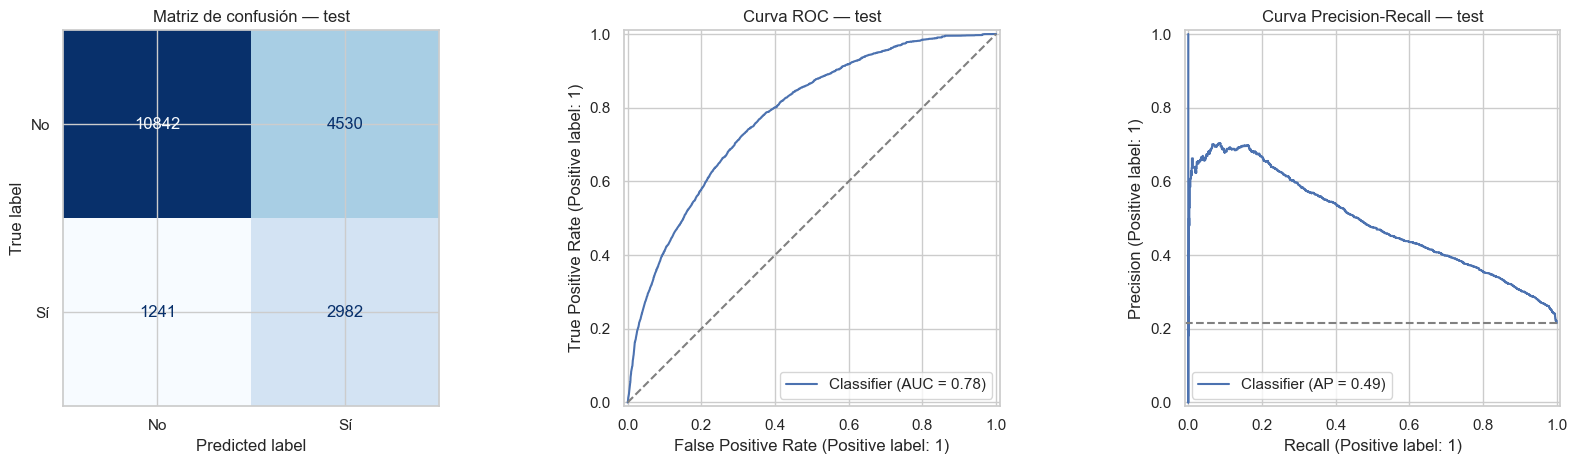

In [32]:
modelo_evaluacion = artefactos.evaluation_pipeline
prediccion_test = modelo_evaluacion.predict(X_test)
puntaje_test = train_model._score_values(modelo_evaluacion, X_test)

figura, ejes = plt.subplots(1, 3, figsize=(17, 4.8))
ConfusionMatrixDisplay.from_predictions(
    y_test, prediccion_test, display_labels=["No", "Sí"], cmap="Blues",
    colorbar=False, ax=ejes[0]
)
ejes[0].set_title("Matriz de confusión — test")
if puntaje_test is not None:
    RocCurveDisplay.from_predictions(y_test, puntaje_test, ax=ejes[1])
    ejes[1].plot([0, 1], [0, 1], "--", color="gray", label="azar")
    ejes[1].set_title("Curva ROC — test")
    PrecisionRecallDisplay.from_predictions(y_test, puntaje_test, ax=ejes[2])
    ejes[2].axhline(y_test.mean(), linestyle="--", color="gray", label="prevalencia")
    ejes[2].set_title("Curva Precision-Recall — test")
else:
    ejes[1].text(0.5, 0.5, "Modelo sin score continuo", ha="center")
    ejes[2].text(0.5, 0.5, "Modelo sin score continuo", ha="center")
plt.tight_layout()
plt.show()


### Prompt 35 — Probar datos no vistos y serializar el pipeline completo

> Muestra ejemplos del test que no participaron en el entrenamiento, con valor real, predicción y puntaje no calibrado. Luego reajusta el modelo escogido con todos los datos, serializa preprocesamiento, balanceo y estimador en un solo archivo, y guarda metadatos y reportes reproducibles.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [33]:
ejemplos_no_vistos = artefactos.test_predictions.copy()
display(ejemplos_no_vistos)

train_model.save_artifacts(artefactos, RAIZ)
ruta_modelo = MODELOS / "pipeline_muestra_medica.joblib"
pipeline_recargado = joblib.load(ruta_modelo)
prediccion_repetida = pipeline_recargado.predict(X.head(3))
assert len(prediccion_repetida) == 3
print(f"Pipeline completo guardado y recargado: {ruta_modelo}")
print("Artefactos generados:")
for ruta in sorted(
    list(MODELOS.glob("*")) + list(REPORTES.glob("*")) + list(FIGURAS.glob("*"))
):
    print("-", ruta.relative_to(RAIZ))


,expedientecum,consecutivocum,cantidad_cum,numero_filas_fuente,numero_cantidades_ingrediente_distintas,numero_principios_activos,numero_vias_administracion,numero_codigos_atc,numero_unidades_medida,numero_unidades_referencia,...,codigo_concentracion,unidad_cum,modalidad,vias_administracion,unidades_medida,familias_atc,tipos_rol,es_muestra_medica,prediccion,puntaje_modelo_no_calibrado
1,20077715,48,100.0,4.0,2.0,2.0,1.0,2.0,1.0,1.0,...,A,U,FABRICAR Y VENDER,ORAL,mg,A,FABRICANTE,0,0,0.134178
3,45821,20,10.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,...,A,U,IMPORTAR Y VENDER,ORAL,mg,C,FABRICANTE | IMPORTADOR,0,1,0.706127
8,19989090,5,4.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,...,A,U,FABRICAR Y VENDER,ORAL,mg,C,FABRICANTE,1,1,0.832854
17,20030605,3,5.0,56.0,28.0,28.0,1.0,1.0,2.0,1.0,...,A,U,IMPORTAR Y VENDER,INTRAVENOSA,g | mg,B,FABRICANTE | IMPORTADOR,0,1,0.565386
18,20094212,3,30.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,A,U,FABRICAR Y VENDER,ORAL,mg,C,FABRICANTE,1,0,0.395311


Pipeline completo guardado y recargado: /Users/bryandiaz/Library/CloudStorage/OneDrive-Personal/Maestria/Segundo semestre/Aprendizaje de maquinas/solucion proyecto final/models/pipeline_muestra_medica.joblib
Artefactos generados:
- figures/comparacion_modelos_cv.png
- figures/curva_precision_recall_test.png
- figures/curva_roc_test.png
- figures/distribucion_objetivo.png
- figures/distribucion_objetivo_cum.png
- figures/faltantes_por_variable.png
- figures/matriz_confusion_test.png
- figures/multiplicidad_filas_por_cum.png
- models/metadata_modelo.json
- models/pipeline_muestra_medica.joblib
- reports/asociaciones_variables.csv
- reports/calidad_datos.csv
- reports/diccionario_datos_original.csv
- reports/metricas_cv_por_fold.csv
- reports/metricas_test.csv
- reports/metricas_validacion_cruzada.csv
- reports/predicciones_datos_no_vistos.csv
- reports/prueba_integracion.csv
- reports/reporte_ydata_profiling.html
- reports/resultados_grid_logistica.csv
- reports/resultados_grid_svm.csv
-

**Nota sobre el puntaje:** cuando el modelo expone `predict_proba`, ese valor
sigue siendo un puntaje de priorización y no una probabilidad calibrada, porque
el entrenamiento incluye sobremuestreo. Una futura versión operativa debería
calibrarlo sobre datos con prevalencia real y validar umbrales según capacidad
de revisión.


### Prompt 36 — Auditar la entrega y dejarla lista para Streamlit

> Verifica que existan notebook, app.py, requirements.txt, README, pipeline, metadatos, métricas, predicciones no vistas e informe ydata. Comprueba que no haya rutas personales, resume resultados con valores calculados y deja los pasos de GitHub/Streamlit sin inventar una URL de despliegue.

**Criterio de revisión humana.** El prompt orienta el paso, pero las
decisiones y conclusiones solo se aceptan si quedan respaldadas por el
código, los datos y las salidas visibles de este cuaderno.


In [34]:
archivos_entrega = {
    "notebook": RAIZ / "notebooks" / "Proyecto_Final_ML_CUM.ipynb",
    "aplicacion": RAIZ / "app.py",
    "requisitos": RAIZ / "requirements.txt",
    "readme": RAIZ / "README.md",
    "pipeline": MODELOS / "pipeline_muestra_medica.joblib",
    "metadatos": MODELOS / "metadata_modelo.json",
    "metricas": REPORTES / "resultados_modelado.json",
    "predicciones_no_vistas": REPORTES / "predicciones_datos_no_vistos.csv",
    "perfil_ydata": REPORTES / "reporte_ydata_profiling.html",
}
auditoria_entrega = pd.DataFrame([
    {
        "entregable": nombre,
        "ruta_relativa": str(ruta.relative_to(RAIZ)),
        "existe": ruta.exists(),
        "bytes": ruta.stat().st_size if ruta.exists() else 0,
    }
    for nombre, ruta in archivos_entrega.items()
])
display(auditoria_entrega)

metricas_finales = resultados["final_test_metrics"]
display(Markdown(
    "## Conclusión calculada\n\n"
    f"El modelo seleccionado **{seleccion['selected_model']}** obtuvo en el "
    f"holdout agrupado F1 = **{metricas_finales['f1']:.4f}**, "
    f"precision = **{metricas_finales['precision']:.4f}** y "
    f"recall = **{metricas_finales['recall']:.4f}**. "
    "La elección se realizó antes de consultar el test y el modelo debe "
    "usarse únicamente como apoyo académico para priorizar revisión."
))

if not auditoria_entrega["existe"].all():
    print(
        "Pendientes: ejecute las celdas de generación correspondientes y "
        "complete app.py/README antes de publicar."
    )
else:
    print("Auditoría local completa. El repositorio queda listo para revisión y despliegue.")


,entregable,ruta_relativa,existe,bytes
0,notebook,notebooks/Proyecto_Final_ML_CUM.ipynb,True,69950
1,aplicacion,app.py,True,30299
2,requisitos,requirements.txt,True,105
3,readme,README.md,True,13702
4,pipeline,models/pipeline_muestra_medica.joblib,True,4515790
5,metadatos,models/metadata_modelo.json,True,9847
6,metricas,reports/resultados_modelado.json,True,18566
7,predicciones_no_vistas,reports/predicciones_datos_no_vistos.csv,True,1167
8,perfil_ydata,reports/reporte_ydata_profiling.html,True,7980306


## Conclusión calculada

El modelo seleccionado **Bagging** obtuvo en el holdout agrupado F1 = **0.5082**, precision = **0.3970** y recall = **0.7061**. La elección se realizó antes de consultar el test y el modelo debe usarse únicamente como apoyo académico para priorizar revisión.

Auditoría local completa. El repositorio queda listo para revisión y despliegue.


## 6. Despliegue y seguimiento

1. Subir los archivos versionados al repositorio público de GitHub.
2. En Streamlit Community Cloud, seleccionar el repositorio, rama `main` y
   archivo principal `app.py`.
3. Verificar un caso con categorías conocidas y otro con categoría desconocida.
4. Registrar en el formato de entrega la URL pública real y una captura de la
   aplicación funcionando.
5. Si cambia el corte del portal, repetir calidad, entrenamiento, evaluación y
   comparación de distribución antes de reemplazar el modelo.

### Limitaciones que permanecen

- El corte es administrativo y puede cambiar con actualizaciones del portal.
- La etiqueta puede reflejar procesos históricos o inconsistencias de captura.
- Las pruebas estadísticas usan pocos folds correlacionados; son evidencia
  auxiliar y no una garantía de superioridad universal.
- El desempeño de test no demuestra validez temporal ni causal.
- El puntaje no está calibrado como probabilidad.
